### Importing libraries

In [94]:
import numpy as np

### Creating linear Regression class

In [52]:
class Linear_regression(): 

    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations


    def fit(self, X, Y):
        self.m, self.n = X.shape

        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y 

        for i in range(self.no_of_iterations):
            self.update_weight()


    def update_weight(self): 
        Y_prediction = self.predict(self.X)

        dw = -(2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
        db = - 2 * np.sum(self.Y - Y_prediction) / self.m 

        self.w = self.w - self.learning_rate * dw 
        self.b = self.b - self.learning_rate * db 


    def predict(self, X):
        return X.dot(self.w) + self.b
        

### importing libraries for prediction

In [95]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

### creating the dataframe

In [54]:
df = pd.read_csv('salary_data.csv')

### Analyzing the data

In [55]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [56]:
df.shape

(30, 2)

In [57]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [58]:
df.std()

YearsExperience        2.837888
Salary             27414.429785
dtype: float64

In [59]:
X = df.drop(columns = "Salary", axis = 1).values

In [60]:
Y = df['Salary'].values

### Splitting into training and testing 

In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [62]:
X_train.shape

(24, 1)

### Training the model

In [88]:
model = Linear_regression( learning_rate = 0.02, no_of_iterations = 1000)

In [89]:
model.fit(X_train, Y_train)

In [90]:
print(model.w[0],model.b)

9570.888860991548 24384.029598697263


In [91]:
test_data_prediction = model.predict(X_test)

In [92]:
test_data_prediction

array([36826.18511799, 34912.00734579, 67453.02947316, 59796.31838437,
       92337.34051174, 81809.36276465])

### plotting the graphs to check

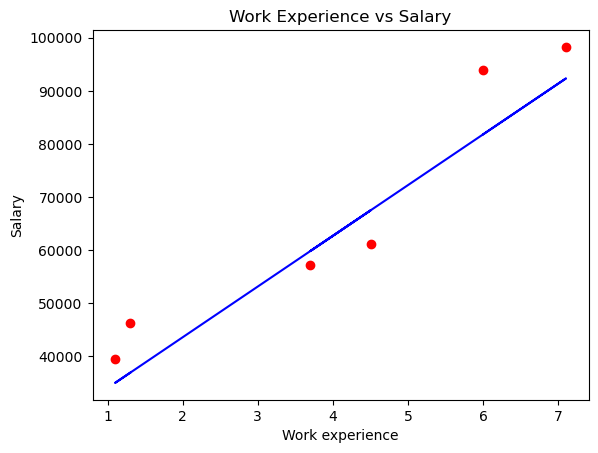

In [93]:
plt.scatter(X_test, Y_test, color = "red") 
plt.plot(X_test, test_data_prediction, color = "blue")
plt.xlabel("Work experience")
plt.ylabel("Salary")
plt.title("Work Experience vs Salary")
plt.show()

### Checking r2 score and mean squared error

In [97]:
print(r2_score(Y_test, test_data_prediction))

0.88863795514416


In [98]:
print(mean_squared_error(Y_test,test_data_prediction))

56166620.797497176
